LAB 4 Notebook 2
====================

Translation with a Seq2Seq Network and Attention
=========================================================================

Two recurrent neural networks work together to transform one sequence to
another. An encoder network condenses an input sequence into a vector,
and a decoder network unfolds that vector into a new sequence.
To improve upon this model we\'ll use an [attention
mechanism](https://arxiv.org/abs/1409.0473), which lets the decoder
learn to focus over a specific range of the input sequence.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/seq2seq.png)

** Code modified from https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

**Author**: [Sean Robertson](https://github.com/spro)




In [87]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loading data files
==================

The data for this project is a set of many thousands of English to
French translation pairs.

Download the data file `eng-fra.txt` from Google drive.



Similar to the character encoding used in the character-level RNN
tutorials, we will be representing each word in a language as a one-hot
vector, or giant vector of zeros except for a single one (at the index
of the word). Compared to the dozens of characters that might exist in a
language, there are many many more words, so the encoding vector is much
larger. We will however cheat a bit and trim the data to only use a few
thousand words per language.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/word-encoding.png)


We\'ll need a unique index per word to use as the inputs and targets of
the networks later. To keep track of all this we will use a helper class
called `Lang` which has word → index (`word2index`) and index → word
(`index2word`) dictionaries, as well as a count of each word
`word2count` which will be used to replace rare words later.


In [88]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

The files are all in Unicode, to simplify we will turn Unicode
characters to ASCII, make everything lowercase, and trim most
punctuation.


In [89]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

To read the data file we will split the file into lines, and then split
lines into pairs. The files are all English → Other Language, so if we
want to translate from Other Language → English I added the `reverse`
flag to reverse the pairs.


In [90]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Read the file and split into lines
    # file in colab /content/sample_data/data/eng-fra.txt
    lines = open('./%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

Since there are a *lot* of example sentences and we want to train
something quickly, we\'ll trim the data set to only relatively short and
simple sentences. Here the maximum length is 10 words (that includes
ending punctuation) and we\'re filtering to sentences that translate to
the form \"I am\" or \"He is\" etc. (accounting for apostrophes replaced
earlier).


In [91]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

The full process for preparing the data is:

-   Read text file and split into lines, split lines into pairs
-   Normalize text, filter by length and content
-   Make word lists from sentences in pairs


In [92]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...


Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['vous etes maigrichon', 'you re skinny']


The Seq2Seq Model
=================

A Recurrent Neural Network, or RNN, is a network that operates on a
sequence and uses its own output as input for subsequent steps.

A [Sequence to Sequence network](https://arxiv.org/abs/1409.3215), or
seq2seq network, or [Encoder Decoder
network](https://arxiv.org/pdf/1406.1078v3.pdf), is a model consisting
of two RNNs called the encoder and decoder. The encoder reads an input
sequence and outputs a single vector, and the decoder reads that vector
to produce an output sequence.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/seq2seq.png)

Unlike sequence prediction with a single RNN, where every input
corresponds to an output, the seq2seq model frees us from sequence
length and order, which makes it ideal for translation between two
languages.



The Encoder
===========

The encoder of a seq2seq network is a RNN that outputs some value for
every word from the input sentence. For every input word the encoder
outputs a vector and a hidden state, and uses the hidden state for the
next input word.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/encoder-network.png)


In [93]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

The Decoder
===========

The decoder is another RNN that takes the encoder output vector(s) and
outputs a sequence of words to create the translation.


Simple Decoder
==============

In the simplest seq2seq decoder we use only last output of the encoder.
This last output is sometimes called the *context vector* as it encodes
context from the entire sequence. This context vector is used as the
initial hidden state of the decoder.

At every step of decoding, the decoder is given an input token and
hidden state. The initial input token is the start-of-string `<SOS>`
token, and the first hidden state is the context vector (the encoder\'s
last hidden state).

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/decoder-network.png)


In [94]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

I encourage you to train and observe the results of this model, but to
save space we\'ll be going straight for the gold and introducing the
Attention Mechanism.


Attention Decoder
=================

If only the context vector is passed between the encoder and decoder,
that single vector carries the burden of encoding the entire sentence.

Attention allows the decoder network to \"focus\" on a different part of
the encoder\'s outputs for every step of the decoder\'s own outputs.
First we calculate a set of *attention weights*. These will be
multiplied by the encoder output vectors to create a weighted
combination. The result (called `attn_applied` in the code) should
contain information about that specific part of the input sequence, and
thus help the decoder choose the right output words.

![](https://i.imgur.com/1152PYf.png)

Calculating the attention weights is done with another feed-forward
layer `attn`, using the decoder\'s input and hidden state as inputs.
Because there are sentences of all sizes in the training data, to
actually create and train this layer we have to choose a maximum
sentence length (input length, for encoder outputs) that it can apply
to. Sentences of the maximum length will use all the attention weights,
while shorter sentences will only use the first few.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/attention-decoder-network.png)

Bahdanau attention, also known as additive attention, is a commonly used
attention mechanism in sequence-to-sequence models, particularly in
neural machine translation tasks. It was introduced by Bahdanau et al.
in their paper titled [Neural Machine Translation by Jointly Learning to
Align and Translate](https://arxiv.org/pdf/1409.0473.pdf). This
attention mechanism employs a learned alignment model to compute
attention scores between the encoder and decoder hidden states. It
utilizes a feed-forward neural network to calculate alignment scores.



In [95]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

Training
========

Preparing Training Data
-----------------------

To train, for each pair we will need an input tensor (indexes of the
words in the input sentence) and target tensor (indexes of the words in
the target sentence). While creating these vectors we will append the
EOS token to both sequences.


In [96]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def pairs_to_dataloader(pairs_list, input_lang, output_lang, batch_size, shuffle=True):
    """Convierte una lista de pares en un DataLoader."""
    n = len(pairs_list)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs_list):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    data = TensorDataset(torch.LongTensor(input_ids).to(device),
                         torch.LongTensor(target_ids).to(device))

    if shuffle:
        sampler = RandomSampler(data)
        return DataLoader(data, sampler=sampler, batch_size=batch_size)
    else:
        return DataLoader(data, batch_size=batch_size, shuffle=False)

def get_dataloader(batch_size, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Prepara los datos con split train/val/test (70-15-15 por defecto).
    Retorna: input_lang, output_lang, train_dataloader, val_dataloader, train_pairs, val_pairs, test_pairs
    """
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
    
    # Shuffle y split
    random.seed(seed)
    shuffled_pairs = pairs.copy()
    random.shuffle(shuffled_pairs)
    
    n = len(shuffled_pairs)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_pairs = shuffled_pairs[:train_end]
    val_pairs = shuffled_pairs[train_end:val_end]
    test_pairs = shuffled_pairs[val_end:]
    
    print(f"Split: {len(train_pairs)} train, {len(val_pairs)} val, {len(test_pairs)} test")
    
    # Crear dataloaders
    train_dataloader = pairs_to_dataloader(train_pairs, input_lang, output_lang, batch_size, shuffle=True)
    val_dataloader = pairs_to_dataloader(val_pairs, input_lang, output_lang, batch_size, shuffle=False)
    
    return input_lang, output_lang, train_dataloader, val_dataloader, train_pairs, val_pairs, test_pairs

Training the Model
==================

To train we run the input sentence through the encoder, and keep track
of every output and the latest hidden state. Then the decoder is given
the `<SOS>` token as its first input, and the last hidden state of the
encoder as its first hidden state.

\"Teacher forcing\" is the concept of using the real target outputs as
each next input, instead of using the decoder\'s guess as the next
input. Using teacher forcing causes it to converge faster.

In [97]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

This is a helper function to print time elapsed and estimated time
remaining given the current time and progress %.


In [98]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

The whole training process looks like this:

-   Start a timer
-   Initialize optimizers and criterion
-   Create set of training pairs
-   Start empty losses array for plotting

Then we call `train` many times and occasionally print the progress (%
of examples, time so far, estimated time) and average loss.


In [99]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=10, plot_every=10):
    #def 100 /100
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        #if epoch % plot_every == 0:
        #    plot_loss_avg = plot_loss_total / plot_every
        #    plot_losses.append(plot_loss_avg)
        #    plot_loss_total = 0

    #showPlot(plot_losses)

Plotting results
================

Plotting is done with matplotlib, using the array of loss values
`plot_losses` saved while training.


In [100]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
%matplotlib inline

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.xlabel('Epochs idx')
    plt.ylabel('Training loss')
    plt.show()


Evaluation
==========

Evaluation is mostly the same as training, but there are no targets so
we simply feed the decoder\'s predictions back to itself for each step.
Every time it predicts a word we add it to the output string, and if it
predicts the EOS token we stop there. We also store the decoder\'s
attention outputs for display later.


In [101]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

We can evaluate random sentences from the training set and print out the
input, target, and output to make some subjective quality judgements:


In [102]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

Training and Evaluating
=======================

With all these helper functions in place (it looks like extra work, but
it makes it easier to run multiple experiments) we can actually
initialize a network and start training.

Remember that the input sentences were heavily filtered. For this small
dataset we can use relatively small networks of 256 hidden nodes and a
single GRU layer. After about 40 minutes on a Laptop CPU we\'ll get
some reasonable results.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">




In [103]:
hidden_size = 32 #def 128
batch_size = 8 # 32

# input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

# encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
# decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

# train(train_dataloader, encoder, decoder, 10 , print_every=5, plot_every=5) #def 80 epochs

Set dropout layers to `eval` mode


In [ ]:
# encoder.eval()
# decoder.eval()
# evaluateRandomly(encoder, decoder)

> vous n etes pas invites
= you aren t invited
< you re not allowed to go <EOS>

> nous sommes freres
= we re brothers
< we re all hungry <EOS>

> vous etes beaux
= you re beautiful
< you re very brave <EOS>

> il est une sorte de celebrite
= he is something of a celebrity
< he s a man of his word <EOS>

> je suis deprime
= i m depressed
< i m so happy <EOS>

> je suis egalement heureux
= i m happy too
< i m glad to see you <EOS>

> tu es tres curieuse
= you re very curious
< you re very good <EOS>

> il n est pas aussi age que mon frere
= he s not as old as my brother
< he s not supposed to be here <EOS>

> elle est capable de tout
= she is capable of anything
< she is afraid to the same age <EOS>

> je me cache
= i m hiding
< i m sorry i m ok <EOS>



Visualizing Attention
=====================

A useful property of the attention mechanism is its highly interpretable
outputs. Because it is used to weight specific encoder outputs of the
input sequence, we can imagine looking where the network is focused most
at each time step.

You could simply run `plt.matshow(attentions)` to see attention output
displayed as a matrix. For a better viewing experience we will do the
extra work of adding axes and labels:


input = il n est pas aussi grand que son pere
output = he s not supposed to be here <EOS>


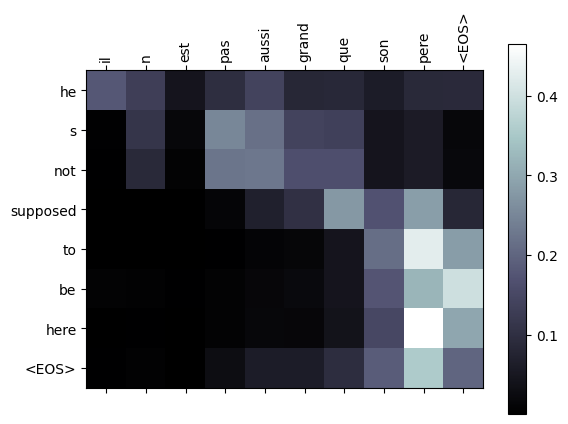

input = je suis trop fatigue pour conduire
output = i m too old for you <EOS>


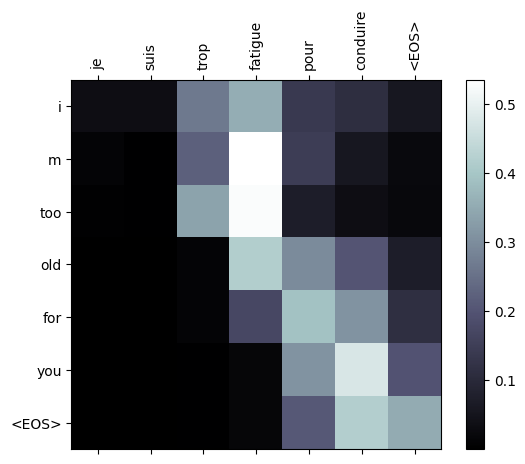

input = je suis desole si c est une question idiote
output = i m sorry i don t recognize you <EOS>


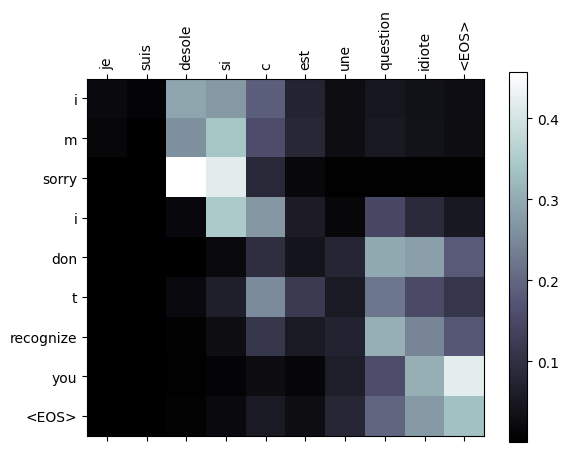

input = je suis reellement fiere de vous
output = i m sorry i don t recognize you <EOS>


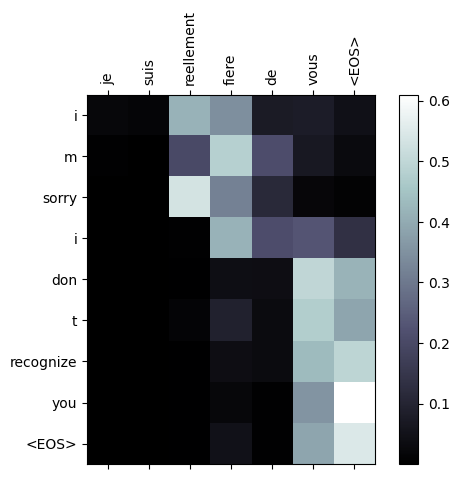

In [105]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Token lists
    input_tokens = input_sentence.split(' ') + ['<EOS>']
    output_tokens = output_words

    # ---- FIX: set tick positions before setting tick labels ----
    ax.set_xticks(range(len(input_tokens)))
    ax.set_yticks(range(len(output_tokens)))

    ax.set_xticklabels(input_tokens, rotation=90)
    ax.set_yticklabels(output_tokens)

    plt.show()
    #plt.clf()
    #plt.close(fig)   # <-- FIX prevents figure accumulation


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])


evaluateAndShowAttention('il n est pas aussi grand que son pere')

evaluateAndShowAttention('je suis trop fatigue pour conduire')

evaluateAndShowAttention('je suis desole si c est une question idiote')

evaluateAndShowAttention('je suis reellement fiere de vous')

Lab4 Exercises
=========

-   Replace the embeddings with pretrained word embeddings such as
    `word2vec` or `GloVe`. Compare
    the training time and results.
-   Try with Luong attention and without the attention module. Compare
    the training time and results.
-   Try with and without Teacher forcing strategy. Compare
    the training time and results.



In [106]:
# =====================================================================
# EXPERIMENTS: Comparaciones sistemáticas
# =====================================================================

# ---------------------------------------------------------------------
# 0. Cargar GloVe embeddings para usar en encoder/decoder
# ---------------------------------------------------------------------
def load_glove_for_vocab(glove_path: str, lang: Lang, embedding_dim: int) -> torch.Tensor:
    """
    Carga embeddings GloVe solo para las palabras del vocabulario.
    Retorna una matriz de embeddings (vocab_size x embedding_dim).
    Palabras no encontradas se inicializan aleatoriamente.
    """
    # Cargar GloVe
    glove_embeddings = {}
    print(f"  Cargando GloVe desde {glove_path}...")
    with open(glove_path, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = torch.tensor([float(x) for x in parts[1:]])
            glove_embeddings[word] = vector
    
    print(f"  GloVe cargado: {len(glove_embeddings)} palabras")
    
    # Crear matriz de embeddings para el vocabulario
    vocab_size = lang.n_words
    embedding_matrix = torch.randn(vocab_size, embedding_dim) * 0.1  # Inicialización aleatoria
    
    found = 0
    for word, idx in lang.word2index.items():
        if word.lower() in glove_embeddings:
            embedding_matrix[idx] = glove_embeddings[word.lower()]
            found += 1
    
    print(f"  Palabras encontradas en GloVe: {found}/{vocab_size} ({100*found/vocab_size:.1f}%)")
    return embedding_matrix


class EncoderRNN_GloVe(nn.Module):
    """Encoder con embeddings GloVe pre-entrenados (congelados o fine-tuned)."""
    def __init__(self, pretrained_embeddings: torch.Tensor, hidden_size: int, 
                 freeze_embeddings: bool = False, dropout_p: float = 0.1):
        super(EncoderRNN_GloVe, self).__init__()
        vocab_size, embedding_dim = pretrained_embeddings.shape
        self.hidden_size = hidden_size
        
        # Embedding layer inicializado con GloVe
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        # Proyección si embedding_dim != hidden_size
        self.projection = nn.Linear(embedding_dim, hidden_size) if embedding_dim != hidden_size else None
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        if self.projection is not None:
            embedded = self.projection(embedded)
        output, hidden = self.gru(embedded)
        return output, hidden


class AttnDecoderRNN_GloVe(nn.Module):
    """Decoder con Bahdanau attention y embeddings GloVe."""
    def __init__(self, pretrained_embeddings: torch.Tensor, hidden_size: int, output_size: int,
                 freeze_embeddings: bool = False, dropout_p: float = 0.1):
        super(AttnDecoderRNN_GloVe, self).__init__()
        vocab_size, embedding_dim = pretrained_embeddings.shape
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        self.projection = nn.Linear(embedding_dim, hidden_size) if embedding_dim != hidden_size else None
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        if self.projection is not None:
            embedded = self.projection(embedded)

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights


# ---------------------------------------------------------------------
# 1. Luong Attention (alternativa a Bahdanau)
# ---------------------------------------------------------------------
class LuongAttention(nn.Module):
    """
    Luong attention (multiplicative attention).
    A diferencia de Bahdanau (additive), usa dot product para calcular scores.
    Paper: "Effective Approaches to Attention-based Neural Machine Translation"
    https://arxiv.org/abs/1508.04025
    """
    def __init__(self, hidden_size, method='dot'):
        super(LuongAttention, self).__init__()
        self.method = method
        self.hidden_size = hidden_size
        
        if method == 'general':
            self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)
        elif method == 'concat':
            self.Wa = nn.Linear(hidden_size * 2, hidden_size, bias=False)
            self.va = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys):
        """
        query: (batch, 1, hidden)  - decoder hidden state
        keys: (batch, seq_len, hidden) - encoder outputs
        """
        if self.method == 'dot':
            # score = query · keys^T
            scores = torch.bmm(query, keys.transpose(1, 2))
        elif self.method == 'general':
            # score = query · Wa · keys^T
            scores = torch.bmm(query, self.Wa(keys).transpose(1, 2))
        elif self.method == 'concat':
            # score = va · tanh(Wa · [query; keys])
            seq_len = keys.size(1)
            query_expanded = query.expand(-1, seq_len, -1)
            concat = torch.cat((query_expanded, keys), dim=2)
            scores = self.va(torch.tanh(self.Wa(concat))).transpose(1, 2)
        
        # scores: (batch, 1, seq_len)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        
        return context, weights


class LuongAttnDecoderRNN(nn.Module):
    """Decoder con Luong attention."""
    def __init__(self, hidden_size, output_size, dropout_p=0.1, attention_method='dot'):
        super(LuongAttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = LuongAttention(hidden_size, method=attention_method)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        # Luong: concatena hidden y context, luego proyecta
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        
        # Primero GRU, luego attention (diferencia clave con Bahdanau)
        gru_output, hidden = self.gru(embedded, hidden)
        
        # Attention sobre el output del GRU
        context, attn_weights = self.attention(gru_output, encoder_outputs)
        
        # Concatenar y proyectar (Luong concat)
        concat_output = torch.cat((gru_output, context), dim=2)
        output = torch.tanh(self.concat(concat_output))
        output = self.out(output)
        
        return output, hidden, attn_weights


# ---------------------------------------------------------------------
# 1. Encoder SIN embedding (one-hot directo)
# ---------------------------------------------------------------------
class EncoderRNN_NoEmbedding(nn.Module):
    """Encoder que usa one-hot vectors directamente (sin embedding layer)."""
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN_NoEmbedding, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # Linear layer que toma one-hot (input_size) y lo proyecta a hidden_size
        self.linear = nn.Linear(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        # Convertir índices a one-hot
        batch_size, seq_len = input.size()
        one_hot = torch.zeros(batch_size, seq_len, self.input_size, device=input.device)
        one_hot.scatter_(2, input.unsqueeze(2), 1)
        
        # Proyectar one-hot a hidden_size
        embedded = self.dropout(self.linear(one_hot))
        output, hidden = self.gru(embedded)
        return output, hidden


# ---------------------------------------------------------------------
# 2. Decoder SIN embedding (one-hot directo)
# ---------------------------------------------------------------------
class DecoderRNN_NoEmbedding(nn.Module):
    """Decoder sin embedding y sin attention."""
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN_NoEmbedding, self).__init__()
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.linear = nn.Linear(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden):
        # Convertir a one-hot
        batch_size = input.size(0)
        one_hot = torch.zeros(batch_size, 1, self.output_size, device=input.device)
        one_hot.scatter_(2, input.unsqueeze(2), 1)
        
        output = self.linear(one_hot)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden


# ---------------------------------------------------------------------
# 3. Decoder con Attention SIN embedding
# ---------------------------------------------------------------------
class AttnDecoderRNN_NoEmbedding(nn.Module):
    """Decoder con attention pero sin embedding layer."""
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN_NoEmbedding, self).__init__()
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.linear = nn.Linear(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        batch_size = input.size(0)
        one_hot = torch.zeros(batch_size, 1, self.output_size, device=input.device)
        one_hot.scatter_(2, input.unsqueeze(2), 1)
        
        embedded = self.dropout(self.linear(one_hot))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

In [107]:
# ---------------------------------------------------------------------
# 4. Training con/sin Teacher Forcing + Validación + Early Stopping
# ---------------------------------------------------------------------

def train_epoch_with_tf_ratio(dataloader, encoder, decoder, encoder_optimizer,
                               decoder_optimizer, criterion, teacher_forcing_ratio=1.0):
    """
    Entrena una época con control de teacher forcing ratio.
    teacher_forcing_ratio: 1.0 = siempre TF, 0.0 = nunca TF
    """
    encoder.train()
    decoder.train()
    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        # Teacher forcing: pasar target_tensor o None
        if teacher_forcing_ratio > 0:
            decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)
        else:
            decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, None)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_loss(dataloader, encoder, decoder, criterion):
    """Calcula la pérdida en un conjunto (validación/test) sin actualizar pesos."""
    encoder.eval()
    decoder.eval()
    total_loss = 0
    
    with torch.no_grad():
        for data in dataloader:
            input_tensor, target_tensor = data
            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)
            loss = criterion(
                decoder_outputs.view(-1, decoder_outputs.size(-1)),
                target_tensor.view(-1)
            )
            total_loss += loss.item()
    
    return total_loss / len(dataloader)


def train_experiment(train_dataloader, val_dataloader, encoder, decoder, n_epochs, 
                     learning_rate=0.001, print_every=10, teacher_forcing_ratio=1.0,
                     patience=3):
    """
    Entrena con validación y early stopping.
    Retorna: tiempo total, train_losses, val_losses, epochs_trained
    """
    start = time.time()
    train_losses = []
    val_losses = []

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()
    
    # Early stopping
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_encoder_state = None
    best_decoder_state = None

    for epoch in range(1, n_epochs + 1):
        # Train
        train_loss = train_epoch_with_tf_ratio(
            train_dataloader, encoder, decoder, 
            encoder_optimizer, decoder_optimizer, criterion,
            teacher_forcing_ratio=teacher_forcing_ratio
        )
        train_losses.append(train_loss)
        
        # Validation
        val_loss = evaluate_loss(val_dataloader, encoder, decoder, criterion)
        val_losses.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            best_encoder_state = encoder.state_dict().copy()
            best_decoder_state = decoder.state_dict().copy()
        else:
            epochs_without_improvement += 1

        if epoch % print_every == 0:
            elapsed = time.time() - start
            print(f'  Epoch {epoch}/{n_epochs} - Train: {train_loss:.4f} - Val: {val_loss:.4f} - Time: {elapsed:.1f}s')
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f'  Early stopping en época {epoch} (patience={patience})')
            break

    # Restaurar mejor modelo
    if best_encoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
        decoder.load_state_dict(best_decoder_state)

    total_time = time.time() - start
    return total_time, train_losses, val_losses, len(train_losses)

In [108]:
# ---------------------------------------------------------------------
# 5. Función auxiliar
# ---------------------------------------------------------------------

def count_parameters(model):
    """Cuenta el número de parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [109]:
# =====================================================================
# 6. EJECUTAR TODOS LOS EXPERIMENTOS
# =====================================================================
# Ajusta estos parámetros según el tiempo disponible

HIDDEN_SIZE = 128
BATCH_SIZE = 64
N_EPOCHS = 50         # Máximo de épocas (early stopping puede parar antes)
PRINT_EVERY = 5
PATIENCE = 3          # Early stopping patience
GLOVE_PATH = "./glove.6B.100d.txt"
GLOVE_DIM = 100

print(f"Configuración: hidden_size={HIDDEN_SIZE}, batch_size={BATCH_SIZE}, max_epochs={N_EPOCHS}, patience={PATIENCE}")
print(f"Device: {device}")
print("=" * 80)

# Cargar datos con split 70-15-15
input_lang, output_lang, train_dataloader, val_dataloader, train_pairs, val_pairs, test_pairs = get_dataloader(BATCH_SIZE)

# Diccionario para guardar resultados y losses
results = {}
all_train_losses = {}
all_val_losses = {}

# =====================================================================
# Experimento 1: BASELINE
# Embedding aprendido + Bahdanau Attention + Teacher Forcing
# =====================================================================
print("\n[1/6] BASELINE: Embedding aprendido + Bahdanau + Teacher Forcing")
enc1 = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
dec1 = AttnDecoderRNN(HIDDEN_SIZE, output_lang.n_words).to(device)
params1 = count_parameters(enc1) + count_parameters(dec1)
print(f"  Parámetros: {params1:,}")

time1, train_losses1, val_losses1, epochs1 = train_experiment(
    train_dataloader, val_dataloader, enc1, dec1, N_EPOCHS, 
    print_every=PRINT_EVERY, teacher_forcing_ratio=1.0, patience=PATIENCE)
results['1_Baseline'] = {'time': time1, 'final_train_loss': train_losses1[-1], 
                         'final_val_loss': val_losses1[-1], 'params': params1, 'epochs': epochs1}
all_train_losses['1_Baseline'] = train_losses1
all_val_losses['1_Baseline'] = val_losses1

# =====================================================================
# Experimento 2: SIN EMBEDDING (One-hot)
# One-hot + Bahdanau Attention + Teacher Forcing
# =====================================================================
print("\n[2/6] SIN EMBEDDING: One-hot + Bahdanau + Teacher Forcing")
enc2 = EncoderRNN_NoEmbedding(input_lang.n_words, HIDDEN_SIZE).to(device)
dec2 = AttnDecoderRNN_NoEmbedding(HIDDEN_SIZE, output_lang.n_words).to(device)
params2 = count_parameters(enc2) + count_parameters(dec2)
print(f"  Parámetros: {params2:,}")

time2, train_losses2, val_losses2, epochs2 = train_experiment(
    train_dataloader, val_dataloader, enc2, dec2, N_EPOCHS,
    print_every=PRINT_EVERY, teacher_forcing_ratio=1.0, patience=PATIENCE)
results['2_NoEmbedding'] = {'time': time2, 'final_train_loss': train_losses2[-1], 
                            'final_val_loss': val_losses2[-1], 'params': params2, 'epochs': epochs2}
all_train_losses['2_NoEmbedding'] = train_losses2
all_val_losses['2_NoEmbedding'] = val_losses2

# =====================================================================
# Experimento 3: CON GLOVE
# GloVe embeddings + Bahdanau Attention + Teacher Forcing
# =====================================================================
print("\n[3/6] CON GLOVE: GloVe embeddings + Bahdanau + Teacher Forcing")
# Cargar GloVe para ambos vocabularios
print("  Cargando embeddings para francés (input)...")
glove_input = load_glove_for_vocab(GLOVE_PATH, input_lang, GLOVE_DIM).to(device)
print("  Cargando embeddings para inglés (output)...")
glove_output = load_glove_for_vocab(GLOVE_PATH, output_lang, GLOVE_DIM).to(device)

enc3 = EncoderRNN_GloVe(glove_input, HIDDEN_SIZE, freeze_embeddings=False).to(device)
dec3 = AttnDecoderRNN_GloVe(glove_output, HIDDEN_SIZE, output_lang.n_words, freeze_embeddings=False).to(device)
params3 = count_parameters(enc3) + count_parameters(dec3)
print(f"  Parámetros: {params3:,}")

time3, train_losses3, val_losses3, epochs3 = train_experiment(
    train_dataloader, val_dataloader, enc3, dec3, N_EPOCHS,
    print_every=PRINT_EVERY, teacher_forcing_ratio=1.0, patience=PATIENCE)
results['3_GloVe'] = {'time': time3, 'final_train_loss': train_losses3[-1], 
                      'final_val_loss': val_losses3[-1], 'params': params3, 'epochs': epochs3}
all_train_losses['3_GloVe'] = train_losses3
all_val_losses['3_GloVe'] = val_losses3

# =====================================================================
# Experimento 4: CON LUONG ATTENTION
# Embedding aprendido + Luong Attention + Teacher Forcing
# =====================================================================
print("\n[4/6] CON LUONG: Embedding aprendido + Luong (general) + Teacher Forcing")
enc4 = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
dec4 = LuongAttnDecoderRNN(HIDDEN_SIZE, output_lang.n_words, attention_method='general').to(device)
params4 = count_parameters(enc4) + count_parameters(dec4)
print(f"  Parámetros: {params4:,}")

time4, train_losses4, val_losses4, epochs4 = train_experiment(
    train_dataloader, val_dataloader, enc4, dec4, N_EPOCHS,
    print_every=PRINT_EVERY, teacher_forcing_ratio=1.0, patience=PATIENCE)
results['4_Luong'] = {'time': time4, 'final_train_loss': train_losses4[-1], 
                      'final_val_loss': val_losses4[-1], 'params': params4, 'epochs': epochs4}
all_train_losses['4_Luong'] = train_losses4
all_val_losses['4_Luong'] = val_losses4

# =====================================================================
# Experimento 5: SIN ATTENTION
# Embedding aprendido + Sin Attention + Teacher Forcing
# =====================================================================
print("\n[5/6] SIN ATTENTION: Embedding aprendido + Sin Attention + Teacher Forcing")
enc5 = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
dec5 = DecoderRNN(HIDDEN_SIZE, output_lang.n_words).to(device)
params5 = count_parameters(enc5) + count_parameters(dec5)
print(f"  Parámetros: {params5:,}")

time5, train_losses5, val_losses5, epochs5 = train_experiment(
    train_dataloader, val_dataloader, enc5, dec5, N_EPOCHS,
    print_every=PRINT_EVERY, teacher_forcing_ratio=1.0, patience=PATIENCE)
results['5_NoAttention'] = {'time': time5, 'final_train_loss': train_losses5[-1], 
                            'final_val_loss': val_losses5[-1], 'params': params5, 'epochs': epochs5}
all_train_losses['5_NoAttention'] = train_losses5
all_val_losses['5_NoAttention'] = val_losses5

# =====================================================================
# Experimento 6: SIN TEACHER FORCING
# Embedding aprendido + Bahdanau Attention + Sin Teacher Forcing
# =====================================================================
print("\n[6/6] SIN TEACHER FORCING: Embedding aprendido + Bahdanau + Sin TF")
enc6 = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
dec6 = AttnDecoderRNN(HIDDEN_SIZE, output_lang.n_words).to(device)
params6 = count_parameters(enc6) + count_parameters(dec6)
print(f"  Parámetros: {params6:,}")

time6, train_losses6, val_losses6, epochs6 = train_experiment(
    train_dataloader, val_dataloader, enc6, dec6, N_EPOCHS,
    print_every=PRINT_EVERY, teacher_forcing_ratio=0.0, patience=PATIENCE)
results['6_NoTeacherForcing'] = {'time': time6, 'final_train_loss': train_losses6[-1], 
                                  'final_val_loss': val_losses6[-1], 'params': params6, 'epochs': epochs6}
all_train_losses['6_NoTeacherForcing'] = train_losses6
all_val_losses['6_NoTeacherForcing'] = val_losses6

print("\n" + "=" * 80)
print("EXPERIMENTOS COMPLETADOS")
print("=" * 80)

Configuración: hidden_size=128, batch_size=64, max_epochs=50, patience=3
Device: cuda
Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
Split: 8011 train, 1717 val, 1717 test

[1/6] BASELINE: Embedding aprendido + Bahdanau + Teacher Forcing
  Parámetros: 1,638,064
  Epoch 5/50 - Train: 1.4636 - Val: 1.5654 - Time: 15.5s
  Epoch 10/50 - Train: 0.9617 - Val: 1.2523 - Time: 31.1s
  Epoch 15/50 - Train: 0.6400 - Val: 1.1103 - Time: 46.7s
  Epoch 20/50 - Train: 0.4269 - Val: 1.0399 - Time: 62.4s
  Epoch 25/50 - Train: 0.2841 - Val: 1.0056 - Time: 77.9s
  Epoch 30/50 - Train: 0.1911 - Val: 0.9997 - Time: 93.4s
  Early stopping en época 32 (patience=3)

[2/6] SIN EMBEDDING: One-hot + Bahdanau + Teacher Forcing
  Parámetros: 1,638,320
  Epoch 5/50 - Train: 2.1309 - Val: 2.1968 - Time: 16.2s
  Epoch 10/50 - Train: 1.5561 - Val: 1.6966 - Time: 32.5s
  Epoch 15/50 - Train: 1.1714 - Val: 1.4729 - Time: 48.8s
  Epoch 20/50

In [110]:
# =====================================================================
# 7. TABLA DE RESULTADOS (con BLEU)
# =====================================================================
from collections import Counter
import csv

# --- Funciones para calcular BLEU ---
def compute_bleu(reference: list[str], candidate: list[str], max_n: int = 4) -> float:
    """Calcula BLEU score simplificado."""
    if len(candidate) == 0:
        return 0.0
    
    precisions = []
    for n in range(1, max_n + 1):
        candidate_ngrams = [tuple(candidate[i:i+n]) for i in range(len(candidate) - n + 1)]
        reference_ngrams = [tuple(reference[i:i+n]) for i in range(len(reference) - n + 1)]
        
        if len(candidate_ngrams) == 0:
            precisions.append(0)
            continue
            
        ref_counts = Counter(reference_ngrams)
        cand_counts = Counter(candidate_ngrams)
        
        matches = sum(min(cand_counts[ng], ref_counts[ng]) for ng in cand_counts)
        precision = matches / len(candidate_ngrams)
        precisions.append(precision)
    
    if 0 in precisions:
        return 0.0
    
    import math
    log_precisions = [math.log(p) if p > 0 else -float('inf') for p in precisions]
    bleu = math.exp(sum(log_precisions) / len(log_precisions))
    bp = min(1.0, math.exp(1 - len(reference) / len(candidate))) if len(candidate) > 0 else 0
    
    return bleu * bp

def evaluate_bleu(encoder, decoder, input_lang, output_lang, pairs, n_samples=200):
    """Calcula BLEU score promedio sobre n_samples."""
    encoder.eval()
    decoder.eval()
    
    bleu_scores = []
    sample_pairs = random.sample(pairs, min(n_samples, len(pairs)))
    
    for pair in sample_pairs:
        try:
            output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
            candidate = [w for w in output_words if w != '<EOS>']
            reference = pair[1].split()
            bleu = compute_bleu(reference, candidate)
            bleu_scores.append(bleu)
        except:
            pass
    
    encoder.train()
    decoder.train()
    return sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0

# --- Crear test_dataloader para calcular test loss ---
test_dataloader = pairs_to_dataloader(test_pairs, input_lang, output_lang, BATCH_SIZE, shuffle=False)
criterion = nn.NLLLoss()

# --- Calcular Test Loss y BLEU para cada modelo ---
print(f"Calculando métricas sobre {len(test_pairs)} frases de TEST...")
models = {
    '1_Baseline': (enc1, dec1),
    '2_NoEmbedding': (enc2, dec2),
    '3_GloVe': (enc3, dec3),
    '4_Luong': (enc4, dec4),
    '5_NoAttention': (enc5, dec5),
    '6_NoTeacherForcing': (enc6, dec6),
}

for name, (enc, dec) in models.items():
    # Test Loss
    test_loss = evaluate_loss(test_dataloader, enc, dec, criterion)
    results[name]['test_loss'] = test_loss
    
    # BLEU
    bleu = evaluate_bleu(enc, dec, input_lang, output_lang, test_pairs, n_samples=len(test_pairs))
    results[name]['bleu'] = bleu
    
    print(f"  {name}: Test Loss = {test_loss:.4f}, BLEU = {bleu:.4f}")

# --- Configuraciones para la tabla ---
configs = [
    ('1_Baseline', 'Aprendido', 'Bahdanau', 'Sí'),
    ('2_NoEmbedding', 'One-hot', 'Bahdanau', 'Sí'),
    ('3_GloVe', 'GloVe', 'Bahdanau', 'Sí'),
    ('4_Luong', 'Aprendido', 'Luong', 'Sí'),
    ('5_NoAttention', 'Aprendido', 'No', 'Sí'),
    ('6_NoTeacherForcing', 'Aprendido', 'Bahdanau', 'No'),
]

# --- Mostrar tabla ---
print("\n" + "=" * 160)
print("  TABLA DE RESULTADOS")
print("=" * 160)
print(f"\n{'#':<3} {'Experimento':<20} │ {'Embedding':^12} │ {'Attention':^12} │ {'TF':^5} │ {'Epochs':^6} │ {'Tiempo':^8} │ {'Val Loss':^10} │ {'Test Loss':^10} │ {'BLEU':^8} │ {'Params':^12}")
print("-" * 160)

for i, (key, emb, attn, tf) in enumerate(configs, 1):
    r = results[key]
    bleu = r.get('bleu', 0)
    marker = " ← BASELINE" if i == 1 else ""
    print(f"{i:<3} {key:<20} │ {emb:^12} │ {attn:^12} │ {tf:^5} │ {r['epochs']:^6} │ {r['time']:>6.1f}s │ {r['final_val_loss']:^10.4f} │ {r['test_loss']:^10.4f} │ {bleu:>7.4f} │ {r['params']:>12,}{marker}")

print("-" * 160)

# --- Guardar en CSV ---
csv_filename = 'seq2seq_results.csv'
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['experimento', 'embedding', 'attention', 'teacher_forcing', 
                  'epochs', 'tiempo_s', 'train_loss', 'val_loss', 'test_loss', 'bleu', 'parametros']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    
    for key, emb, attn, tf in configs:
        r = results[key]
        writer.writerow({
            'experimento': key,
            'embedding': emb,
            'attention': attn,
            'teacher_forcing': tf,
            'epochs': r['epochs'],
            'tiempo_s': round(r['time'], 2),
            'train_loss': round(r['final_train_loss'], 4),
            'val_loss': round(r['final_val_loss'], 4),
            'test_loss': round(r['test_loss'], 4),
            'bleu': round(r.get('bleu', 0), 4),
            'parametros': r['params']
        })

print(f"\n✓ Resultados guardados en '{csv_filename}'")

Calculando métricas sobre 1717 frases de TEST...


  1_Baseline: Test Loss = 0.9921, BLEU = 0.2478
  2_NoEmbedding: Test Loss = 1.1464, BLEU = 0.2129
  3_GloVe: Test Loss = 1.0537, BLEU = 0.2253
  4_Luong: Test Loss = 1.0630, BLEU = 0.1770
  5_NoAttention: Test Loss = 1.1860, BLEU = 0.0887
  6_NoTeacherForcing: Test Loss = 1.3407, BLEU = 0.1704

  TABLA DE RESULTADOS

#   Experimento          │  Embedding   │  Attention   │  TF   │ Epochs │  Tiempo  │  Val Loss  │ Test Loss  │   BLEU   │    Params   
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1   1_Baseline           │  Aprendido   │   Bahdanau   │  Sí   │   32   │   99.6s │   1.0099   │   0.9921   │  0.2478 │    1,638,064 ← BASELINE
2   2_NoEmbedding        │   One-hot    │   Bahdanau   │  Sí   │   41   │  133.6s │   1.1798   │   1.1464   │  0.2129 │    1,638,320
3   3_GloVe              │    GloVe     │   Bahdanau   │  Sí   │   43   │  143.4s │   1.0766   │   1.0537  

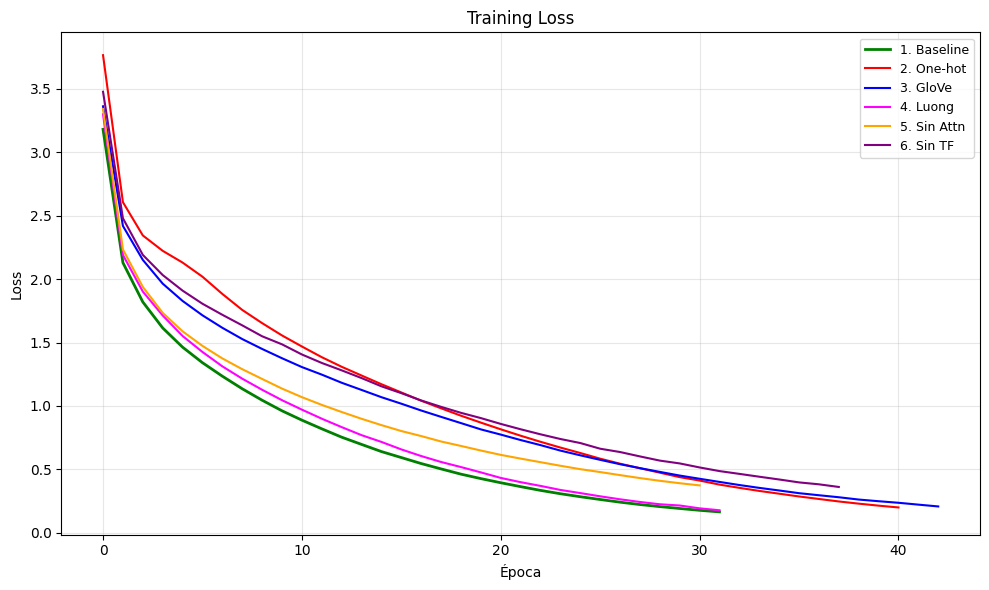

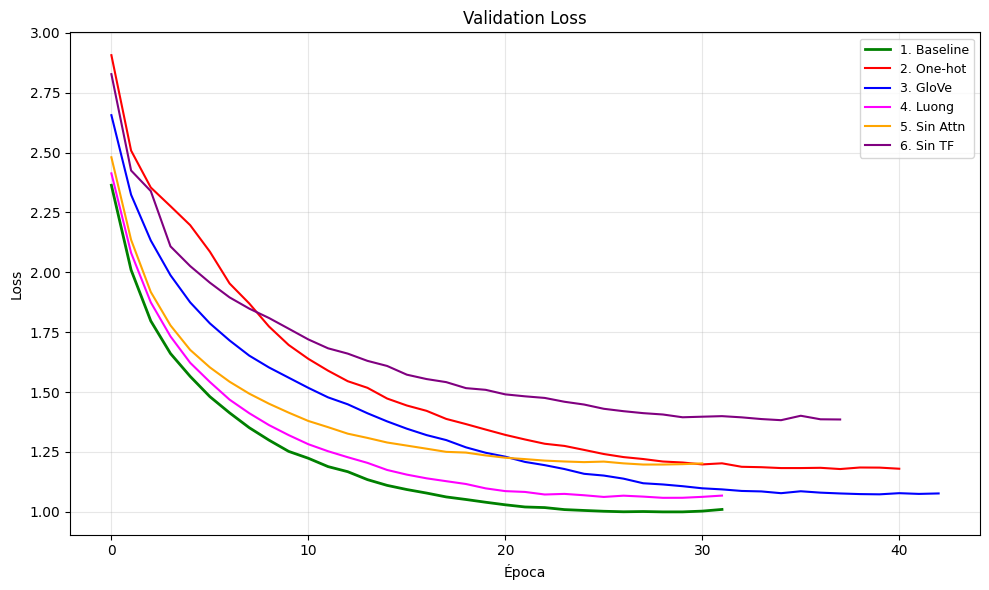

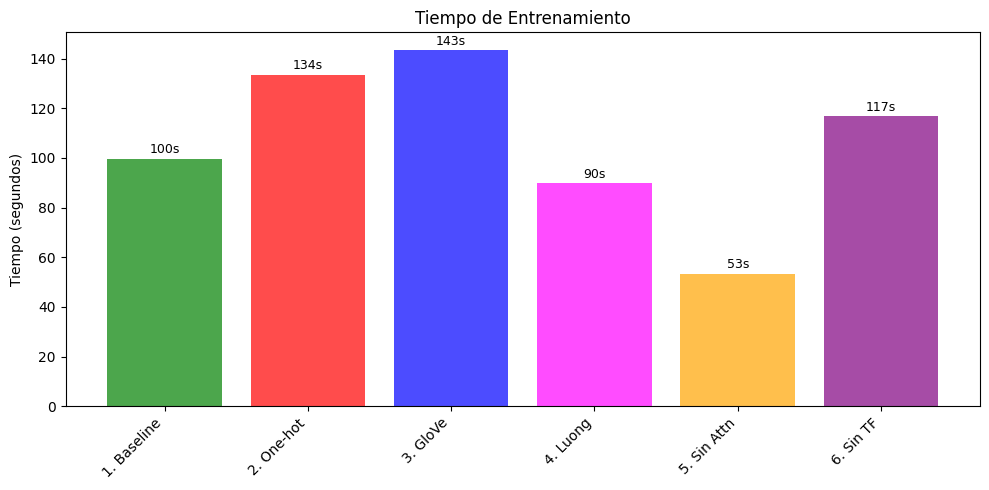

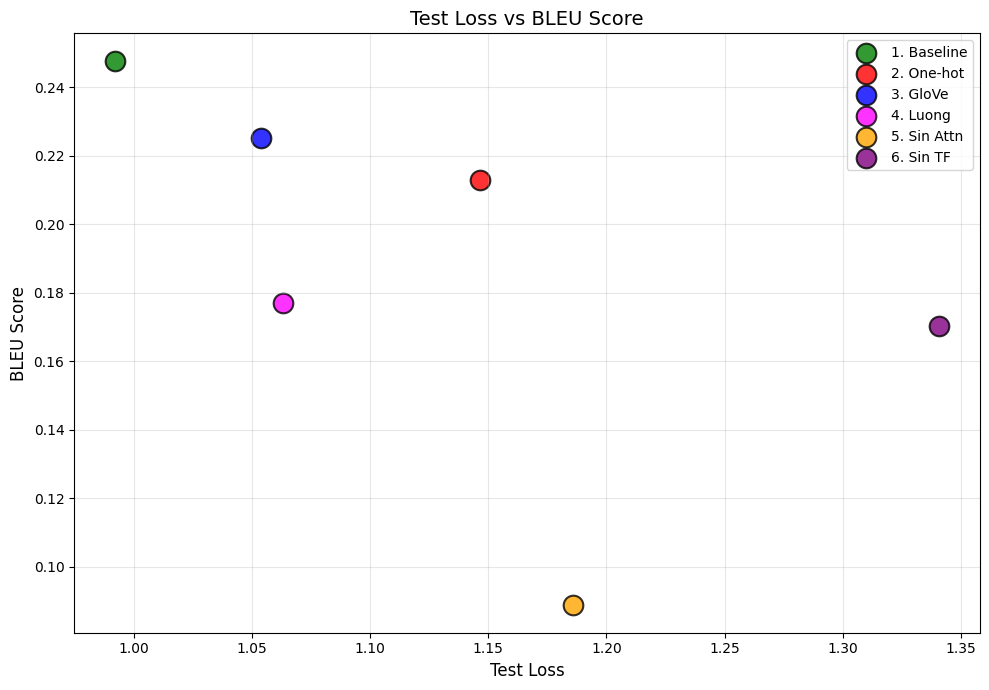

In [111]:
# =====================================================================
# 8. GRÁFICOS COMPARATIVOS
# =====================================================================

# Colores y etiquetas para los 6 experimentos
colors = ['green', 'red', 'blue', 'magenta', 'orange', 'purple']
labels = ['1. Baseline', '2. One-hot', '3. GloVe', '4. Luong', '5. Sin Attn', '6. Sin TF']
exp_keys = ['1_Baseline', '2_NoEmbedding', '3_GloVe', '4_Luong', '5_NoAttention', '6_NoTeacherForcing']

# --- Gráfico 1: Training Loss ---
plt.figure(figsize=(10, 6))
for i, key in enumerate(exp_keys):
    plt.plot(all_train_losses[key], label=labels[i], color=colors[i], 
             linewidth=2 if i == 0 else 1.5)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Gráfico 2: Validation Loss ---
plt.figure(figsize=(10, 6))
for i, key in enumerate(exp_keys):
    plt.plot(all_val_losses[key], label=labels[i], color=colors[i], 
             linewidth=2 if i == 0 else 1.5)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Gráfico 3: Comparación de tiempos ---
plt.figure(figsize=(10, 5))
times = [results[k]['time'] for k in exp_keys]
bars = plt.bar(labels, times, color=colors, alpha=0.7)
plt.ylabel('Tiempo (segundos)')
plt.title('Tiempo de Entrenamiento')
plt.xticks(rotation=45, ha='right')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{t:.0f}s', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# --- Gráfico 4: Test Loss vs BLEU ---
plt.figure(figsize=(10, 7))
for i, key in enumerate(exp_keys):
    r = results[key]
    plt.scatter(r['test_loss'], r.get('bleu', 0), s=200, c=colors[i], 
                label=labels[i], alpha=0.8, edgecolors='black', linewidths=1.5)
plt.xlabel('Test Loss', fontsize=12)
plt.ylabel('BLEU Score', fontsize=12)
plt.title('Test Loss vs BLEU Score', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

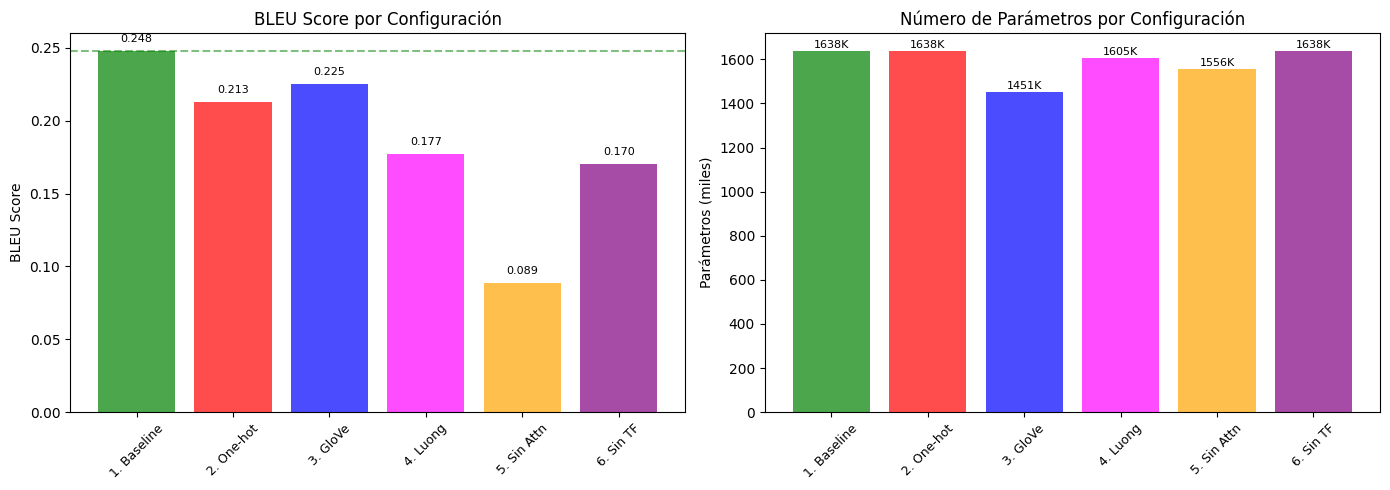

In [112]:
# =====================================================================
# 9. GRÁFICAS ADICIONALES
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: BLEU Score comparativo
ax1 = axes[0]
bleu_values = [results[k].get('bleu', 0) for k in exp_keys]
bars1 = ax1.bar(labels, bleu_values, color=colors, alpha=0.7)
ax1.set_ylabel('BLEU Score')
ax1.set_title('BLEU Score por Configuración')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.axhline(y=bleu_values[0], color='green', linestyle='--', alpha=0.5, label='Baseline')
for bar, v in zip(bars1, bleu_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Número de parámetros
ax2 = axes[1]
param_values = [results[k]['params'] for k in exp_keys]
bars2 = ax2.bar(labels, [p/1000 for p in param_values], color=colors, alpha=0.7)
ax2.set_ylabel('Parámetros (miles)')
ax2.set_title('Número de Parámetros por Configuración')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
for bar, p in zip(bars2, param_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{p/1000:.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [113]:
# =====================================================================
# 10. EJEMPLOS DE TRADUCCIÓN COMPARADOS (del conjunto TEST)
# =====================================================================

# Seleccionar frases aleatorias del TEST set
n_examples = 5
example_pairs = random.sample(test_pairs, n_examples)

print("=" * 100)
print("  COMPARACIÓN DE TRADUCCIONES (TEST set)")
print("=" * 100)

for pair in example_pairs:
    sentence = pair[0]
    correct = pair[1]
    
    print(f"\n📝 Input: {sentence}")
    print(f"   ✓ Referencia: {correct}")
    print(f"   {'Modelo':<20} │ {'Traducción':<50}")
    print(f"   {'-'*75}")
    
    for name, (enc, dec) in models.items():
        try:
            output_words, _ = evaluate(enc, dec, sentence, input_lang, output_lang)
            translation = ' '.join(output_words)
        except:
            translation = "[ERROR]"
        
        short_name = name.replace('_', ' ')
        print(f"   {short_name:<20} │ {translation:<50}")

print("\n" + "=" * 100)

  COMPARACIÓN DE TRADUCCIONES (TEST set)

📝 Input: vous n etes pas fatigues si ?
   ✓ Referencia: you re not tired are you ?
   Modelo               │ Traducción                                        
   ---------------------------------------------------------------------------
   1 Baseline           │ you re not that are you ? <EOS>                   
   2 NoEmbedding        │ you re not so sure are you ? <EOS>                
   3 GloVe              │ you re not tired are you ? <EOS>                  
   4 Luong              │ you are not kind of cute isn t you ?              
   5 NoAttention        │ you re not upset are you ? <EOS>                  
   6 NoTeacherForcing   │ you re not married are you ? ? <EOS>              

📝 Input: tu es fascinant
   ✓ Referencia: you re fascinating
   Modelo               │ Traducción                                        
   ---------------------------------------------------------------------------
   1 Baseline           │ you are blind

# Conclusiones

Para este cuaderno, hemos realizado 6 experimentos, con los siguientes hiperparámetros:

- hidden_size: 128
- batch_size: 64
- n_epochs: 50 (con early stopping)
- patience: 3
- glove_dim: 100
- learning_rate: 0.001
- Train-Val-Test: 70-15-15

Los experimentos han sido los siguientes:

1. Baseline: Embedding aprendido + Bahdanau + Teacher Forcing
2. One-hot: One-hot + Bahdanau + Teacher Forcing
3. GloVe: GloVe + Bahdanau + Teacher Forcing
4. Luong: Embedding aprendido + Luong + Teacher Forcing
5. Sin Attn: Embedding aprendido + Sin Attention + Teacher Forcing
6. Sin TF: Embedding aprendido + Bahdanau + Sin Teacher Forcing

La gráfica más interesante para comparar los resultados ha sido la de Loss vs BLEU. Aquí podemos ver claramente que el mejor modelo, tanto por la métrica del BLEU Score (común para tareas de traducción), como para la pérdida en test, es el modelo baseline. Este modelo, con embeddings aprendidos, atención Bahdanau y Teacher Forcing consigue un BLEU Score de 0.248. 

El techo histórico para arquitecturas Seq2Seq en traducciones eng-fra se sitúa en 0.389 (Google, 2016), aunque con un dataset mucho mayor y frases más complejas.

En segundo lugar tenemos el modelo que usa embeddings de GloVe y en tercer lugar one-hot encoding. Esto nos dice que lo mejor que podemos usar para este problema son los embeddings aprendidos, ya que estos marcan la diferencia entre los mejores resultados. Sin embargo, el embedding concreto que usemos no es tan crítico, ya que las tres opciones dan buenos resultados. Eso sí, aumentan considerablemente el tiempo de entrenamiento (1.3x con One-hot y 1.4x con GloVe).

Usando la atención de Luong, reducimos el tiempo de entrenamiento en un 10%, pero solamente obtenemos un BLEU score de 0.177, aunque sí que es importante usar mecanismos de atención, ya que sin ellos obtenemos el peor resultado de todos (0.089).

Por último, si quitamos el Teacher Forcing, aumentamos en un 17% el tiempo de entrenamiento y reducimos notablemente el BLEU Score (0.17).